## Basic Rotterdam-Antwerp trip  
This notebook shows the simple route without locks. There are two routes: Nieuwe Maas and Oude Maas. Some edges had to be removed or forces for these routes. The speed is fixed at 4m/s (which is correct now according to the last cell). 


## TO DO
1. X Clean
2. V Finalise simple route (add reduced depth at chosen setions) 
3. X Test with 2nd vessel
4. Copy simple route and test with Volkerak 
5. Visualise fuel consumption (kg/km and kg/h, first over volkerak then simple route) --> table 
6. Finish analysis Volkerak (extract 2 other cases)
7. Calibrate the other cases (-> create lock objects with the right parametrs) 
8. Find way to run cases in a single code (vessels, routes??, lock) 



## 0. Import libraries

In [1]:
# packages used for creating and geo-locating the graph
import networkx as nx
# New import for shallow parts 
from networkx.utils import pairwise
import shapely

# packages related to the simulation (creating the vessel, running the simulation)
import datetime
import pickle
import simpy
import opentnsim
import opentnsim.fis as fis
from opentnsim.core.logutils import logbook2eventtable
from opentnsim.core.plotutils import generate_vessel_gantt_chart
from opentnsim.graph import mixins as graph_module
from opentnsim.graph.calculations import calculate_length_of_edge

# packages related to the energy module 
from opentnsim.energy.logutils import (
    add_energy_attributes_to_eventtable,
    add_fuel_attributes_to_event_table,
    add_H2_attributes_to_event_table)

# packages needed for inspecting the output
import pandas as pd
import geopandas as gpd

# packages needed for plotting
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# plot libraries
import folium

import numpy as np

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 2.2.2.dev47+gbe28de4fe.d20260122


In [2]:
%load_ext autoreload
%autoreload 2

## 0. Load useful methods 

### A) Network functions

In [3]:
# Method to remove edges  
def safe_remove_edge(G, u, v):
    if G.has_edge(u, v):
        G.remove_edge(u, v)
        G.remove_edge(v,u)
        print(f"Removed edge: {u} -> {v} (both directions)")
    else:
        print(f"Edge {u} -> {v} does not exist (already removed).")

In [4]:
# Method to find the closest node
def find_closest_node(G,point):
    distances, idx = nodes_gdf.sindex.nearest(point)
    # return nodes_gdf.iloc[idx[0]].name
    return nodes_gdf.iloc[idx[0]]

### Other methods
Segers also introduces these methods. But I believe those are not needed in the current opentnsim version in combination with the energy module. 

B) Metods to calculate vessel properties <br>
C) Methods to calculate the resistance, power and corresponding emissions <br>
D) Calculate the energy use and emission per time step

### 1. Define object classes

--> moved this to later just before 3. Run simulation 

### 2. Create graph
Next we create a network (a graph) along which the vessel can move. For this case we use the Fairway Information System graph, and make the vessel sail from a container terminal at the Maasvlakte to the Kreekrak locks

#### 2.1 Load FIS graph

In [5]:
# load the processed version from the Fairway Information System graph provided by Rijkswaterstaat
# For FIS version 0.3 
# FG = fis.load_network(version="0.3")

# # Make graph directed 
# FG = FG.to_directed()

with open('FG_correct_distances.pickle', 'rb') as handle:
    FG = pickle.load(handle)
FG = FG.to_directed()

In [6]:
# Printing the data per edge to see what the names are. Check if there is water depth info
for u, v, data in FG.edges(data=True):
    print (u, "->", v)
    print(data)
    break

8861095 -> 8864054
{'GeoType': 'section', 'Name': 'Vaarwegvak van 0 tot 2 - H', 'Length': 2.346, 'GeneralDepth': nan, 'GeneralLength': nan, 'GeneralWidth': nan, 'SeaFairingDepth': nan, 'PushedLength': nan, 'PushedWidth': nan, 'GeneralHeight': nan, 'SeaFairingLength': nan, 'SeaFairingWidth': nan, 'CoupledLength': nan, 'CoupledWidth': nan, 'PushedDepth': nan, 'WidePushedDepth': nan, 'CoupledDepth': nan, 'WidePushedLength': nan, 'WidePushedWidth': nan, 'SeaFairingHeight': nan, 'Id_navigability': nan, 'Classification': nan, 'Code': nan, 'Description': nan, 'length_deg': nan, 'length': 0.0255813258548747, 'Wkt': 'LINESTRING (3.54535894046351 51.727661900382, 3.5602008295784 51.742791566037, 3.56379034355024 51.7453141508194)', 'StartJunctionId': '8861095', 'EndJunctionId': '8864054', 'subgraph': 0, 'length_m': 2345.572872686835, 'geometry': <LINESTRING (3.545 51.728, 3.56 51.743, 3.564 51.745)>}


In [7]:
# FG.nodes[('B4705_B')]['LINESTRING']
FG.nodes[('B4705_B')]

{'n': 'B4705_B',
 'X': 4.485519786010358,
 'Y': 51.90947209143337,
 'geometry': <POINT (4.486 51.909)>,
 'Wkt': 'POINT (4.4855197860103582 51.9094720914333720)'}

#### 2.2 Remove edges 
Edges need to be removed to ensure that the vessels sail representative routes.

In [8]:
# Remove Spui (very shallow waterway so most vessels are not able to pass this) 
safe_remove_edge(FG, 'S22992990_A', 'S22992990_B')

# Remove recreational bergediepsluis (not for IWT vessels) 
safe_remove_edge(FG, 'L51819_A', 'L51819_B')

# Remove recreational lock volkerak (not for IWT vessels) 
safe_remove_edge(FG, 'B46500_A', 'B46500_B')

# Remove Rietbaan in nieuwe Maas route (this edge creates a loop)
# TO DO: find out why this removes Noord instead of Rietbaan?? --> difference not so relevant though
safe_remove_edge(FG, '8863048', '8866570') 

# Remove edge at start of shallow SR part (around Noordplaat Island) 
# safe_remove_edge(FG, "8862801", "8862255")

Removed edge: S22992990_A -> S22992990_B (both directions)
Removed edge: L51819_A -> L51819_B (both directions)
Removed edge: B46500_A -> B46500_B (both directions)
Removed edge: 8863048 -> 8866570 (both directions)


#### 2.3 Plan route 

In [9]:
maasvlakte     = shapely.Point(4.056694, 51.947162)
volkerak       = shapely.Point(4.409331, 51.690440)
kreekrak       = shapely.Point(4.228202, 51.461103)
meerhout       = shapely.Point(5.096662, 51.098779)
antwerp        = shapely.Point(4.344243, 51.279407)
botlek         = shapely.Point(4.315013, 51.894716)
erasmus_bridge = shapely.Point(4.486020, 51.908346)
krammer        = shapely.Point(4.160114, 51.661751)
hansweert      = shapely.Point(4.010556, 51.455824)
Noord1         = shapely.Point(4.622453,51.8854942)
Noord2         = shapely.Point(4.669784,51.8240557)
Scheldt_Rhine1 = shapely.Point(4.194823,51.6149341) 
Scheldt_Rhine2 = shapely.Point(4.220736,51.4943026)
antwerp_ZB     = shapely.Point(4.262775,51.3438188)
antwerp_SR     = shapely.Point(4.296340,51.3441803)

In [10]:
nodes_gdf = gpd.GeoDataFrame(FG.nodes.values(), index=FG.nodes.keys())

In [11]:
# Find closest nodes for the locations
# Start locations
maasvlakte_node  = find_closest_node(FG,maasvlakte)
botlek_node      = find_closest_node(FG,botlek)
# Locks
volkerak_node   = find_closest_node(FG,volkerak)
kreekrak_node    = find_closest_node(FG,kreekrak)
krammer_node     = find_closest_node(FG,krammer)
hansweert_node   = find_closest_node(FG,hansweert)
# End locations
antwerp_node     = find_closest_node(FG,antwerp)
meerhout_node    = find_closest_node(FG,meerhout)
# Nieuwe maas route needs to pass the Erasmus bridge
erasmus_bridge_node      = find_closest_node(FG,erasmus_bridge)
# Shallow water start and end points
Noord1_node = find_closest_node(FG,Noord1)
Noord2_node = find_closest_node(FG,Noord2)
Scheldt_Rhine1_node = find_closest_node(FG,Scheldt_Rhine1)
Scheldt_Rhine2_node = find_closest_node(FG,Scheldt_Rhine2)
# End points
antwerp_ZB_node = find_closest_node(FG,antwerp_ZB)
antwerp_SR_node = find_closest_node(FG,antwerp_SR)

In [12]:
# Use network x to create the different routes
route_OM_SR = nx.shortest_path(FG, botlek_node.name, antwerp_SR_node.name, weight='length_m')

route_NM_SR = (
    nx.shortest_path(FG, botlek_node.name, erasmus_bridge_node.name, weight='length_m')
    + nx.shortest_path(FG, erasmus_bridge_node.name, antwerp_SR_node.name, weight='length_m')[1:])

route_OM_ZB = (
    nx.shortest_path(FG, botlek_node.name, hansweert_node.name, weight='length_m')
    + nx.shortest_path(FG, hansweert_node.name, antwerp_ZB_node.name, weight='length_m')[1:])

route_NM_ZB = (
    nx.shortest_path(FG, botlek_node.name, erasmus_bridge_node.name, weight='length_m')
    +nx.shortest_path(FG, erasmus_bridge_node.name, hansweert_node.name, weight='length_m')[1:]
    + nx.shortest_path(FG, hansweert_node.name, antwerp_ZB_node.name, weight='length_m')[1:])

shallow_NM = nx.shortest_path(FG, Noord1_node.name, Noord2_node.name, weight='length_m')
shallow_SR = nx.shortest_path(FG, Scheldt_Rhine1_node.name, Scheldt_Rhine2_node.name, weight='length_m')

### 2.2 Create water depth info on edges + visualize on network 

In [13]:
# shallow_NM_set = set(shallow_NM)
# shallow_SR_set = set(shallow_SR)
# # Add this to make sure that things go smooth around Noordplaat island
# # shallow_SR_set.update({"8862801", "8864138"})
# # shallow_SR_set.update({"8864138", "8862801"})
# # shallow_SR_set.update({"8865797 ", "8862801"})
# # shallow_SR_set.update({"8862801 ", "8865797"}) 

# # Sailing from node 8867060 to node 8868351
# # shallow_SR_set.difference_update({"8867060", "8868351"}) 
# # shallow_SR_set.difference_update({"8868351", "8867060"}) 

# for u, v in FG.edges():
#     FG.edges[u, v]["GeneralDepth"] = 6
    
#     # Reduce water depth for shallow parts of the route
#     # Note that this also reduced the water depth for the branches of the route
#     if u in shallow_NM_set or v in shallow_NM_set:
#         FG.edges[u, v]["GeneralDepth"] = 4.4
#     if u in shallow_SR_set or v in shallow_SR_set:
#         FG.edges[u, v]["GeneralDepth"] = 4.3

# # Force this specific segment to be 6m around Noordplaat
# # FG.edges["8867060", "8868351"]["GeneralDepth"] = 6

In [14]:
shallow_NM_set = set(shallow_NM)
shallow_SR_set = set(shallow_SR)

for u, v in FG.edges():
    FG.edges[u, v]["GeneralDepth"] = 6
    # Reduce water depth for shallow parts of the route
    if u in shallow_NM_set or v in shallow_NM_set:
        FG.edges[u, v]["GeneralDepth"] = 4.4
    if u in shallow_SR_set or v in shallow_SR_set:
        FG.edges[u, v]["GeneralDepth"] = 4.3

In [15]:
print(shallow_NM_set)
print(shallow_SR_set)

{'Berth149', 'B43523_B', '8863131', '8861666', '8863048', '8866570', '8866686', '8865140', 'B43523_A'}
{'B30667_A', 'B37463_A', '8866632', '8867083', '8868095', '8868133', 'B37463_B', '8865574', 'B30667_B', 'B9108_A', 'B9108_B'}


In [16]:
# Dit is dus voor al die vertakkingen 
length_shallow_NM = sum(
    FG.edges[u, v]["length_m"]
    for u, v in FG.edges()
    if u in shallow_NM_set or v in shallow_NM_set)/1000

print(length_shallow_NM)

length_shallow_SR = sum(
    FG.edges[u, v]["length_m"]
    for u, v in FG.edges()
    if u in shallow_SR_set or v in shallow_SR_set)/1000

print(length_shallow_SR)

39.793711356903955
56.81550483830306


### 1. Define object classes
This was af the begining of the code first but moved it here. 

In [17]:
# make your preferred Vessel class out of available mix-ins.
Vessel = type(
    "Vessel", 
    (
        opentnsim.core.Movable,                            # Needs to be on top 
        opentnsim.energy.mixins.ConsumesEnergy,
        opentnsim.core.Identifiable,                       # allows to give the object a name and a random ID,
        opentnsim.core.vessel_properties.VesselProperties,
        opentnsim.core.ExtraMetadata,
    ), 
    {}
)

### 3. Run simulation

In [18]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel. 
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    while True:
        yield from vessel.move()
        
        if vessel.geometry == nx.get_node_attributes(env.graph, "geometry")[vessel.route[-1]]:
            break

In [19]:
# start simpy environment

simulation_start = datetime.datetime(2024, 1, 1, 0, 0, 0)
env = simpy.Environment(initial_time=simulation_start.timestamp())
env.epoch = simulation_start

env.graph = FG

data_vessel_1 = {
    "env": env,
    "name": 'M8 loaded passing OM+SR',           # you can give the vessel an arbitratry name
    "type": 'P_tot_given=P_installed', # This indicates the vessel class. This info is mainly informative.
    "L": 110,                   # m
    "B": 11.4,                  # m
    "T": 3.5,                   # m
    "v": 4,                     # m/s If None: this value is calculated based on P_tot_given
    # "v": None,                  # m/s If None: this value is calculated based on P_tot_given
    "safety_margin": 0.2,       # for tanker vessel with sandy bed the safety margin is recommended as 0.2 m 
    "h_squat": False,           # if the ship should squat while moving, set to True, otherwise set to False
    "P_installed": 1750.0,      # kW
    # "P_tot_given": 1750.0*0.35,      # 
    "P_tot_given": None,        # kW If None: this value is calculated value based on speed
    "bulbous_bow": False,       # if a vessel has no bulbous_bow, set to False; otherwise set to True.
    "karpov_correction": True, # if False, don't apply the karpov correction, if True, apply the karpov correction
    "P_hotel_perc": 0.05,       # 0: all power goes to propulsion
    "P_hotel": None,            # None: calculate P_hotel from percentage
    "x": 2,                     # number of propellers
    "L_w": 3.0 ,
    "C_B": 0.85,                # block coefficient 
    "C_year": 1990,             # engine build year
    "arrival_time": datetime.datetime(2024, 1, 1, 0, 0, 0),
    "geometry": env.graph.nodes[route_OM_SR[0]]['geometry'],
    "route": route_OM_SR,             # the route to sail
}  # 

data_vessel_2 = {
    "env": env,
    "name": 'M8 unloaded passing OM+SR',           # you can give the vessel an arbitratry name
    "type": 'P_tot_given=P_installed', # This indicates the vessel class. This info is mainly informative.
    "L": 110,                   # m
    "B": 11.4,                  # m
    "T": 1.8,                   # m
    "v": 4,                     # m/s If None: this value is calculated based on P_tot_given
    # "v": None,                  # m/s If None: this value is calculated based on P_tot_given
    "safety_margin": 0.2,       # for tanker vessel with sandy bed the safety margin is recommended as 0.2 m 
    "h_squat": False,           # if the ship should squat while moving, set to True, otherwise set to False
    "P_installed": 1750.0,      # kW
    # "P_tot_given": 1750.0*0.35,      # 
    "P_tot_given": None,        # kW If None: this value is calculated value based on speed
    "bulbous_bow": False,       # if a vessel has no bulbous_bow, set to False; otherwise set to True.
    "karpov_correction": True, # if False, don't apply the karpov correction, if True, apply the karpov correction
    "P_hotel_perc": 0.05,       # 0: all power goes to propulsion
    "P_hotel": None,            # None: calculate P_hotel from percentage
    "x": 2,                     # number of propellers
    "L_w": 3.0 ,
    "C_B": 0.85,                # block coefficient 
    "C_year": 1990,             # engine build year
    "arrival_time": datetime.datetime(2024, 1, 1, 0, 0, 0),
    "geometry": env.graph.nodes[route_OM_SR[0]]['geometry'],
    "route": route_OM_SR,             # the route to sail
}  # 

data_vessel_3 = {
    "env": env,
    "name": 'M8 loaded passing NM+SR',           # you can give the vessel an arbitratry name
    "type": 'P_tot_given=P_installed', # This indicates the vessel class. This info is mainly informative.
    "L": 110,                   # m
    "B": 11.4,                  # m
    "T": 3.5,                   # m
    "v": 4,                     # m/s If None: this value is calculated based on P_tot_given
    # "v": None,                  # m/s If None: this value is calculated based on P_tot_given
    "safety_margin": 0.2,       # for tanker vessel with sandy bed the safety margin is recommended as 0.2 m 
    "h_squat": False,           # if the ship should squat while moving, set to True, otherwise set to False
    "P_installed": 1750.0,      # kW
    # "P_tot_given": 1750.0*0.35,      # 
    "P_tot_given": None,        # kW If None: this value is calculated value based on speed
    "bulbous_bow": False,       # if a vessel has no bulbous_bow, set to False; otherwise set to True.
    "karpov_correction": True, # if False, don't apply the karpov correction, if True, apply the karpov correction
    "P_hotel_perc": 0.05,       # 0: all power goes to propulsion
    "P_hotel": None,            # None: calculate P_hotel from percentage
    "x": 2,                     # number of propellers
    "L_w": 3.0 ,
    "C_B": 0.85,                # block coefficient 
    "C_year": 1990,             # engine build year
    "arrival_time": datetime.datetime(2024, 1, 1, 0, 0, 0),
    "geometry": env.graph.nodes[route_NM_SR[0]]['geometry'],
    "route": route_NM_SR,             # the route to sail
}  # 

data_vessel_4 = {
    "env": env,
    "name": 'M8 unloaded passing NM+SR',           # you can give the vessel an arbitratry name
    "type": 'P_tot_given=P_installed', # This indicates the vessel class. This info is mainly informative.
    "L": 110,                   # m
    "B": 11.4,                  # m
    "T": 1.8,                   # m
    "v": 4,                     # m/s If None: this value is calculated based on P_tot_given
    # "v": None,                  # m/s If None: this value is calculated based on P_tot_given
    "safety_margin": 0.2,       # for tanker vessel with sandy bed the safety margin is recommended as 0.2 m 
    "h_squat": False,           # if the ship should squat while moving, set to True, otherwise set to False
    "P_installed": 1750.0,      # kW
    # "P_tot_given": 1750.0*0.35,      # 
    "P_tot_given": None,        # kW If None: this value is calculated value based on speed
    "bulbous_bow": False,       # if a vessel has no bulbous_bow, set to False; otherwise set to True.
    "karpov_correction": True, # if False, don't apply the karpov correction, if True, apply the karpov correction
    "P_hotel_perc": 0.05,       # 0: all power goes to propulsion
    "P_hotel": None,            # None: calculate P_hotel from percentage
    "x": 2,                     # number of propellers
    "L_w": 3.0 ,
    "C_B": 0.85,                # block coefficient 
    "C_year": 1990,             # engine build year
    "arrival_time": datetime.datetime(2024, 1, 1, 0, 0, 0),
    "geometry": env.graph.nodes[route_NM_SR[0]]['geometry'],
    "route": route_NM_SR,             # the route to sail
}  # 

data_vessel_5 = {
    "env": env,
    "name": 'M8 loaded passing OM+ZB',           # you can give the vessel an arbitratry name
    "type": 'P_tot_given=P_installed', # This indicates the vessel class. This info is mainly informative.
    "L": 110,                   # m
    "B": 11.4,                  # m
    "T": 3.5,                   # m
    "v": 4,                     # m/s If None: this value is calculated based on P_tot_given
    # "v": None,                  # m/s If None: this value is calculated based on P_tot_given
    "safety_margin": 0.2,       # for tanker vessel with sandy bed the safety margin is recommended as 0.2 m 
    "h_squat": False,           # if the ship should squat while moving, set to True, otherwise set to False
    "P_installed": 1750.0,      # kW
    # "P_tot_given": 1750.0*0.35,      # 
    "P_tot_given": None,        # kW If None: this value is calculated value based on speed
    "bulbous_bow": False,       # if a vessel has no bulbous_bow, set to False; otherwise set to True.
    "karpov_correction": True, # if False, don't apply the karpov correction, if True, apply the karpov correction
    "P_hotel_perc": 0.05,       # 0: all power goes to propulsion
    "P_hotel": None,            # None: calculate P_hotel from percentage
    "x": 2,                     # number of propellers
    "L_w": 3.0 ,
    "C_B": 0.85,                # block coefficient 
    "C_year": 1990,             # engine build year
    "arrival_time": datetime.datetime(2024, 1, 1, 0, 0, 0),
    "geometry": env.graph.nodes[route_OM_ZB[0]]['geometry'],
    "route": route_OM_ZB,             # the route to sail
}  # 

data_vessel_6 = {
    "env": env,
    "name": 'M8 unloaded passing OM+ZB',           # you can give the vessel an arbitratry name
    "type": 'P_tot_given=P_installed', # This indicates the vessel class. This info is mainly informative.
    "L": 110,                   # m
    "B": 11.4,                  # m
    "T": 1.8,                   # m
    "v": 4,                     # m/s If None: this value is calculated based on P_tot_given
    # "v": None,                  # m/s If None: this value is calculated based on P_tot_given
    "safety_margin": 0.2,       # for tanker vessel with sandy bed the safety margin is recommended as 0.2 m 
    "h_squat": False,           # if the ship should squat while moving, set to True, otherwise set to False
    "P_installed": 1750.0,      # kW
    # "P_tot_given": 1750.0*0.35,      # 
    "P_tot_given": None,        # kW If None: this value is calculated value based on speed
    "bulbous_bow": False,       # if a vessel has no bulbous_bow, set to False; otherwise set to True.
    "karpov_correction": True, # if False, don't apply the karpov correction, if True, apply the karpov correction
    "P_hotel_perc": 0.05,       # 0: all power goes to propulsion
    "P_hotel": None,            # None: calculate P_hotel from percentage
    "x": 2,                     # number of propellers
    "L_w": 3.0 ,
    "C_B": 0.85,                # block coefficient 
    "C_year": 1990,             # engine build year
    "arrival_time": datetime.datetime(2024, 1, 1, 0, 0, 0),
    "geometry": env.graph.nodes[route_OM_ZB[0]]['geometry'],
    "route": route_OM_ZB,             # the route to sail
}  # 

data_vessel_7 = {
    "env": env,
    "name": 'M8 loaded passing NM+ZB',           # you can give the vessel an arbitratry name
    "type": 'P_tot_given=P_installed', # This indicates the vessel class. This info is mainly informative.
    "L": 110,                   # m
    "B": 11.4,                  # m
    "T": 3.5,                   # m
    "v": 4,                     # m/s If None: this value is calculated based on P_tot_given
    # "v": None,                  # m/s If None: this value is calculated based on P_tot_given
    "safety_margin": 0.2,       # for tanker vessel with sandy bed the safety margin is recommended as 0.2 m 
    "h_squat": False,           # if the ship should squat while moving, set to True, otherwise set to False
    "P_installed": 1750.0,      # kW
    # "P_tot_given": 1750.0*0.35,      # 
    "P_tot_given": None,        # kW If None: this value is calculated value based on speed
    "bulbous_bow": False,       # if a vessel has no bulbous_bow, set to False; otherwise set to True.
    "karpov_correction": True, # if False, don't apply the karpov correction, if True, apply the karpov correction
    "P_hotel_perc": 0.05,       # 0: all power goes to propulsion
    "P_hotel": None,            # None: calculate P_hotel from percentage
    "x": 2,                     # number of propellers
    "L_w": 3.0 ,
    "C_B": 0.85,                # block coefficient 
    "C_year": 1990,             # engine build year
    "arrival_time": datetime.datetime(2024, 1, 1, 0, 0, 0),
    "geometry": env.graph.nodes[route_NM_ZB[0]]['geometry'],
    "route": route_NM_ZB,             # the route to sail
}  # 

data_vessel_8 = {
    "env": env,
    "name": 'M8 unloaded passing NM+ZB',           # you can give the vessel an arbitratry name
    "type": 'P_tot_given=P_installed', # This indicates the vessel class. This info is mainly informative.
    "L": 110,                   # m
    "B": 11.4,                  # m
    "T": 1.8,                   # m
    "v": 4,                     # m/s If None: this value is calculated based on P_tot_given
    # "v": None,                  # m/s If None: this value is calculated based on P_tot_given
    "safety_margin": 0.2,       # for tanker vessel with sandy bed the safety margin is recommended as 0.2 m 
    "h_squat": False,           # if the ship should squat while moving, set to True, otherwise set to False
    "P_installed": 1750.0,      # kW
    # "P_tot_given": 1750.0*0.35,      # 
    "P_tot_given": None,        # kW If None: this value is calculated value based on speed
    "bulbous_bow": False,       # if a vessel has no bulbous_bow, set to False; otherwise set to True.
    "karpov_correction": True, # if False, don't apply the karpov correction, if True, apply the karpov correction
    "P_hotel_perc": 0.05,       # 0: all power goes to propulsion
    "P_hotel": None,            # None: calculate P_hotel from percentage
    "x": 2,                     # number of propellers
    "L_w": 3.0 ,
    "C_B": 0.85,                # block coefficient 
    "C_year": 1990,             # engine build year
    "arrival_time": datetime.datetime(2024, 1, 1, 0, 0, 0),
    "geometry": env.graph.nodes[route_NM_ZB[0]]['geometry'],
    "route": route_NM_ZB,             # the route to sail
}  # 

# create an instance of the Vessel class using the input dict data_vessel
vessel_1 = Vessel(**data_vessel_1)
# vessel_2 = Vessel(**data_vessel_2)
vessel_3 = Vessel(**data_vessel_3)
# vessel_4 = Vessel(**data_vessel_4)
vessel_5 = Vessel(**data_vessel_5)
# vessel_6 = Vessel(**data_vessel_6)
vessel_7 = Vessel(**data_vessel_7)
# vessel_8 = Vessel(**data_vessel_8)

# start the simulation
env.process(mission(env, vessel_1))
# env.process(mission(env, vessel_2))
env.process(mission(env, vessel_3))
# env.process(mission(env, vessel_4))
env.process(mission(env, vessel_5))
# env.process(mission(env, vessel_6))
env.process(mission(env, vessel_7))
# env.process(mission(env, vessel_8))

env.run()

### 4. Inspect output
We can now inspect  the simulation output by inspecting the _vessel.logbook_. Note that the _Log_ mix-in was included when we added _Movable_. The _vessel.logbook_ keeps track of the moving activities of the vessel. For each discrete event OpenTNSim logs an event message, the start/stop time and the location. The _vessel.logbook_ is of type dict. For convenient inspection it can be loaded into a Pandas dataframe. 

In [20]:
# load the logbook data into a dataframe
df = pd.DataFrame.from_dict(vessel_1.logbook)

print("'{}' logbook data:".format(vessel_1.name))  
print('')

display(df)

'M8 loaded passing OM+SR' logbook data:



,Message,Timestamp,Value,Geometry
0,Sailing from node 8861716 to node B17838816_B ...,2024-01-01 00:00:00.000000,0.000000,POINT (4.32003340516321 51.8944476699094)
1,Sailing from node 8861716 to node B17838816_B ...,2024-01-01 00:11:11.550698,2686.202792,POINT (4.331101754547955 51.87131584461907)
2,Sailing from node B17838816_B to node B1783881...,2024-01-01 00:11:11.550698,2686.202792,POINT (4.331101754547955 51.87131584461907)
3,Sailing from node B17838816_B to node B1783881...,2024-01-01 00:11:14.127663,2696.510652,POINT (4.331149675825261 51.871228074742795)
4,Sailing from node B17838816_A to node 8865803 ...,2024-01-01 00:11:14.127663,2696.510652,POINT (4.331149675825261 51.871228074742795)
...,...,...,...,...
143,Sailing from node 30986149 to node B41483_A stop,2024-01-01 06:59:13.791615,100615.166458,POINT (4.300364070999526 51.36902814369938)
144,Sailing from node B41483_A to node B41483_B start,2024-01-01 06:59:13.791615,100615.166458,POINT (4.300364070999526 51.36902814369938)
145,Sailing from node B41483_A to node B41483_B stop,2024-01-01 06:59:16.572228,100626.288911,POINT (4.300367045878951 51.368928187958716)
146,Sailing from node B41483_B to node 35228583 start,2024-01-01 06:59:16.572228,100626.288911,POINT (4.300367045878951 51.368928187958716)


The inspection of the logbook data shows that Vessel moved from its origin (*Node 0*) to its destination (*Node 1*). The print statements show that the length of the route from *Node 0* to *Node 1* is exactly 100 km. At a given speed of 1 m/s the trip duration should be exactly 100000 seconds, as is indeed shown to be the case.

In [21]:
# df_eventtable = logbook2eventtable([vessel_1, vessel_2, vessel_3, vessel_4, vessel_5, vessel_6, vessel_7, vessel_8])
df_eventtable = logbook2eventtable([vessel_1, vessel_3, vessel_5, vessel_7])
# df_eventtable = logbook2eventtable([vessel_3])
# df_eventtable.head(3)

pd.set_option("display.max_rows", None)
df_eventtable
# pd.reset_option("display.max_rows")


,object id,object name,main activity name,subactivity name,start location,stop location,start time,stop time,distance (m),duration (s)
0,b45f7c48-b3f5-4650-864b-73fff3191a4d,M8 loaded passing OM+SR,Sailing from node 8861716 to node B17838816_B,,POINT (4.32003340516321 51.8944476699094),POINT (4.331101754547955 51.87131584461907),2024-01-01 00:00:00,2024-01-01 00:11:12,2686.202792,671.550698
1,b45f7c48-b3f5-4650-864b-73fff3191a4d,M8 loaded passing OM+SR,Sailing from node B17838816_B to node B17838816_A,,POINT (4.331101754547955 51.87131584461907),POINT (4.331149675825261 51.871228074742795),2024-01-01 00:11:12,2024-01-01 00:11:14,10.307860,2.576965
2,b45f7c48-b3f5-4650-864b-73fff3191a4d,M8 loaded passing OM+SR,Sailing from node B17838816_A to node 8865803,,POINT (4.331149675825261 51.871228074742795),POINT (4.33350300310146 51.866917854826305),2024-01-01 00:11:14,2024-01-01 00:13:21,506.202732,126.550683
3,b45f7c48-b3f5-4650-864b-73fff3191a4d,M8 loaded passing OM+SR,Sailing from node 8865803 to node 8862143,,POINT (4.33350300310146 51.866917854826305),POINT (4.33506263254959 51.864172165469505),2024-01-01 00:13:21,2024-01-01 00:14:42,323.821755,80.955439
4,b45f7c48-b3f5-4650-864b-73fff3191a4d,M8 loaded passing OM+SR,Sailing from node 8862143 to node B42792_B,,POINT (4.33506263254959 51.864172165469505),POINT (4.340053200020321 51.859600597806946),2024-01-01 00:14:42,2024-01-01 00:17:15,613.910812,153.477703
5,b45f7c48-b3f5-4650-864b-73fff3191a4d,M8 loaded passing OM+SR,Sailing from node B42792_B to node B42792_A,,POINT (4.340053200020321 51.859600597806946),POINT (4.340125260900426 51.859531369318596),2024-01-01 00:17:15,2024-01-01 00:17:17,9.168936,2.292234
6,b45f7c48-b3f5-4650-864b-73fff3191a4d,M8 loaded passing OM+SR,Sailing from node B42792_A to node 8867784,,POINT (4.340125260900426 51.859531369318596),POINT (4.34220631701808 51.8572692964818),2024-01-01 00:17:17,2024-01-01 00:18:30,289.645631,72.411408
7,b45f7c48-b3f5-4650-864b-73fff3191a4d,M8 loaded passing OM+SR,Sailing from node 8867784 to node 8864737,,POINT (4.34220631701808 51.8572692964818),POINT (4.43200716599724 51.8367377400882),2024-01-01 00:18:30,2024-01-01 00:47:36,6984.781815,1746.195453
8,b45f7c48-b3f5-4650-864b-73fff3191a4d,M8 loaded passing OM+SR,Sailing from node 8864737 to node 8867023,,POINT (4.43200716599724 51.8367377400882),POINT (4.52760808152354 51.8302649043596),2024-01-01 00:47:36,2024-01-01 01:16:12,6865.180650,1716.295163
9,b45f7c48-b3f5-4650-864b-73fff3191a4d,M8 loaded passing OM+SR,Sailing from node 8867023 to node 8863810,,POINT (4.52760808152354 51.8302649043596),POINT (4.56623163072507 51.812486619297296),2024-01-01 01:16:12,2024-01-01 01:33:06,4054.016523,1013.504130


In [22]:
# add energy attributes to the minimum event table
# df_eventtable_energy = add_energy_attributes_to_eventtable(df_eventtable, [vessel_1, vessel_2, vessel_3, vessel_4, vessel_5, vessel_6, vessel_7, vessel_8])        
df_eventtable_energy = add_energy_attributes_to_eventtable(df_eventtable, [vessel_1, vessel_3, vessel_5, vessel_7])     
# df_eventtable_energy = add_energy_attributes_to_eventtable(df_eventtable, [vessel_3])        

# pd.set_option('display.max_columns', None)
df_eventtable_energy

,object id,object name,main activity name,subactivity name,start location,stop location,start time,stop time,distance (m),duration (s),velocity (m/s),waterdepth (m),waterway width (m),current (m/s),P_tot (kW),P_given (kW),P_installed (kW),total_energy (kWh)
0,b45f7c48-b3f5-4650-864b-73fff3191a4d,M8 loaded passing OM+SR,Sailing from node 8861716 to node B17838816_B,,POINT (4.32003340516321 51.8944476699094),POINT (4.331101754547955 51.87131584461907),2024-01-01 00:00:00,2024-01-01 00:11:12,2686.202792,671.550698,4.000000,6.0,None,0.0,619.443950,619.443950,1750.0,115.552227
1,b45f7c48-b3f5-4650-864b-73fff3191a4d,M8 loaded passing OM+SR,Sailing from node B17838816_B to node B17838816_A,,POINT (4.331101754547955 51.87131584461907),POINT (4.331149675825261 51.871228074742795),2024-01-01 00:11:12,2024-01-01 00:11:14,10.307860,2.576965,4.000000,6.0,None,0.0,619.443923,619.443923,1750.0,0.443413
2,b45f7c48-b3f5-4650-864b-73fff3191a4d,M8 loaded passing OM+SR,Sailing from node B17838816_A to node 8865803,,POINT (4.331149675825261 51.871228074742795),POINT (4.33350300310146 51.866917854826305),2024-01-01 00:11:14,2024-01-01 00:13:21,506.202732,126.550683,4.000000,6.0,None,0.0,619.443948,619.443948,1750.0,21.775293
3,b45f7c48-b3f5-4650-864b-73fff3191a4d,M8 loaded passing OM+SR,Sailing from node 8865803 to node 8862143,,POINT (4.33350300310146 51.866917854826305),POINT (4.33506263254959 51.864172165469505),2024-01-01 00:13:21,2024-01-01 00:14:42,323.821755,80.955439,4.000000,6.0,None,0.0,619.443946,619.443946,1750.0,13.929821
4,b45f7c48-b3f5-4650-864b-73fff3191a4d,M8 loaded passing OM+SR,Sailing from node 8862143 to node B42792_B,,POINT (4.33506263254959 51.864172165469505),POINT (4.340053200020321 51.859600597806946),2024-01-01 00:14:42,2024-01-01 00:17:15,613.910812,153.477703,4.000000,6.0,None,0.0,619.443950,619.443950,1750.0,26.408565
5,b45f7c48-b3f5-4650-864b-73fff3191a4d,M8 loaded passing OM+SR,Sailing from node B42792_B to node B42792_A,,POINT (4.340053200020321 51.859600597806946),POINT (4.340125260900426 51.859531369318596),2024-01-01 00:17:15,2024-01-01 00:17:17,9.168936,2.292234,4.000000,6.0,None,0.0,619.443968,619.443968,1750.0,0.394420
6,b45f7c48-b3f5-4650-864b-73fff3191a4d,M8 loaded passing OM+SR,Sailing from node B42792_A to node 8867784,,POINT (4.340125260900426 51.859531369318596),POINT (4.34220631701808 51.8572692964818),2024-01-01 00:17:17,2024-01-01 00:18:30,289.645631,72.411408,4.000000,6.0,None,0.0,619.443946,619.443946,1750.0,12.459669
7,b45f7c48-b3f5-4650-864b-73fff3191a4d,M8 loaded passing OM+SR,Sailing from node 8867784 to node 8864737,,POINT (4.34220631701808 51.8572692964818),POINT (4.43200716599724 51.8367377400882),2024-01-01 00:18:30,2024-01-01 00:47:36,6984.781815,1746.195453,4.000000,6.0,None,0.0,619.443951,619.443951,1750.0,300.463947
8,b45f7c48-b3f5-4650-864b-73fff3191a4d,M8 loaded passing OM+SR,Sailing from node 8864737 to node 8867023,,POINT (4.43200716599724 51.8367377400882),POINT (4.52760808152354 51.8302649043596),2024-01-01 00:47:36,2024-01-01 01:16:12,6865.180650,1716.295163,4.000000,6.0,None,0.0,619.443949,619.443949,1750.0,295.319071
9,b45f7c48-b3f5-4650-864b-73fff3191a4d,M8 loaded passing OM+SR,Sailing from node 8867023 to node 8863810,,POINT (4.52760808152354 51.8302649043596),POINT (4.56623163072507 51.812486619297296),2024-01-01 01:16:12,2024-01-01 01:33:06,4054.016523,1013.504130,4.000000,6.0,None,0.0,619.443952,619.443952,1750.0,174.391390


In [23]:
# add fuel attributes to the minimum event table with energy attributes
# df_eventtable_energy_fuel = add_fuel_attributes_to_event_table(df_eventtable_energy, [vessel_1, vessel_2, vessel_3, vessel_4, vessel_5, vessel_6, vessel_7, vessel_8])
# df_eventtable_energy_fuel = add_fuel_attributes_to_event_table(df_eventtable_energy, [vessel_1, vessel_3, vessel_5, vessel_7])

# pd.set_option('display.max_columns', None)
# df_eventtable_energy_fuel

In [24]:
# add H2 attributes to the minimum event table with energy attributes
# df_eventtable_energy_H2 = add_H2_attributes_to_event_table(df_eventtable_energy, [vessel_1, vessel_2, vessel_3, vessel_4, vessel_5, vessel_6, vessel_7, vessel_8])
df_eventtable_energy_H2 = add_H2_attributes_to_event_table(df_eventtable_energy, [vessel_1, vessel_3, vessel_5, vessel_7])

pd.set_option('display.max_columns', None)
df_eventtable_energy_H2

,object id,object name,main activity name,subactivity name,start location,stop location,start time,stop time,distance (m),duration (s),velocity (m/s),waterdepth (m),waterway width (m),current (m/s),P_tot (kW),P_given (kW),P_installed (kW),total_energy (kWh),H2_consumption (g),H2_consumption_m (g/m),H2_consumption_s (g/s)
0,b45f7c48-b3f5-4650-864b-73fff3191a4d,M8 loaded passing OM+SR,Sailing from node 8861716 to node B17838816_B,,POINT (4.32003340516321 51.8944476699094),POINT (4.331101754547955 51.87131584461907),2024-01-01 00:00:00,2024-01-01 00:11:12,2686.202792,671.550698,4.000000,6.0,None,0.0,619.443950,619.443950,1750.0,115.552227,7967.007018,2.965899,11.863597
1,b45f7c48-b3f5-4650-864b-73fff3191a4d,M8 loaded passing OM+SR,Sailing from node B17838816_B to node B17838816_A,,POINT (4.331101754547955 51.87131584461907),POINT (4.331149675825261 51.871228074742795),2024-01-01 00:11:12,2024-01-01 00:11:14,10.307860,2.576965,4.000000,6.0,None,0.0,619.443923,619.443923,1750.0,0.443413,30.572074,2.965899,11.863597
2,b45f7c48-b3f5-4650-864b-73fff3191a4d,M8 loaded passing OM+SR,Sailing from node B17838816_A to node 8865803,,POINT (4.331149675825261 51.871228074742795),POINT (4.33350300310146 51.866917854826305),2024-01-01 00:11:14,2024-01-01 00:13:21,506.202732,126.550683,4.000000,6.0,None,0.0,619.443948,619.443948,1750.0,21.775293,1501.346330,2.965899,11.863597
3,b45f7c48-b3f5-4650-864b-73fff3191a4d,M8 loaded passing OM+SR,Sailing from node 8865803 to node 8862143,,POINT (4.33350300310146 51.866917854826305),POINT (4.33506263254959 51.864172165469505),2024-01-01 00:13:21,2024-01-01 00:14:42,323.821755,80.955439,4.000000,6.0,None,0.0,619.443946,619.443946,1750.0,13.929821,960.422718,2.965899,11.863597
4,b45f7c48-b3f5-4650-864b-73fff3191a4d,M8 loaded passing OM+SR,Sailing from node 8862143 to node B42792_B,,POINT (4.33506263254959 51.864172165469505),POINT (4.340053200020321 51.859600597806946),2024-01-01 00:14:42,2024-01-01 00:17:15,613.910812,153.477703,4.000000,6.0,None,0.0,619.443950,619.443950,1750.0,26.408565,1820.797655,2.965899,11.863597
5,b45f7c48-b3f5-4650-864b-73fff3191a4d,M8 loaded passing OM+SR,Sailing from node B42792_B to node B42792_A,,POINT (4.340053200020321 51.859600597806946),POINT (4.340125260900426 51.859531369318596),2024-01-01 00:17:15,2024-01-01 00:17:17,9.168936,2.292234,4.000000,6.0,None,0.0,619.443968,619.443968,1750.0,0.394420,27.194142,2.965899,11.863598
6,b45f7c48-b3f5-4650-864b-73fff3191a4d,M8 loaded passing OM+SR,Sailing from node B42792_A to node 8867784,,POINT (4.340125260900426 51.859531369318596),POINT (4.34220631701808 51.8572692964818),2024-01-01 00:17:17,2024-01-01 00:18:30,289.645631,72.411408,4.000000,6.0,None,0.0,619.443946,619.443946,1750.0,12.459669,859.059775,2.965899,11.863597
7,b45f7c48-b3f5-4650-864b-73fff3191a4d,M8 loaded passing OM+SR,Sailing from node 8867784 to node 8864737,,POINT (4.34220631701808 51.8572692964818),POINT (4.43200716599724 51.8367377400882),2024-01-01 00:18:30,2024-01-01 00:47:36,6984.781815,1746.195453,4.000000,6.0,None,0.0,619.443951,619.443951,1750.0,300.463947,20716.159611,2.965899,11.863597
8,b45f7c48-b3f5-4650-864b-73fff3191a4d,M8 loaded passing OM+SR,Sailing from node 8864737 to node 8867023,,POINT (4.43200716599724 51.8367377400882),POINT (4.52760808152354 51.8302649043596),2024-01-01 00:47:36,2024-01-01 01:16:12,6865.180650,1716.295163,4.000000,6.0,None,0.0,619.443949,619.443949,1750.0,295.319071,20361.434555,2.965899,11.863597
9,b45f7c48-b3f5-4650-864b-73fff3191a4d,M8 loaded passing OM+SR,Sailing from node 8867023 to node 8863810,,POINT (4.52760808152354 51.8302649043596),POINT (4.56623163072507 51.812486619297296),2024-01-01 01:16:12,2024-01-01 01:33:06,4054.016523,1013.504130,4.000000,6.0,None,0.0,619.443952,619.443952,1750.0,174.391390,12023.804838,2.965899,11.863597


In [25]:
# df_eventtable_energy_H2['velocity'] = df_eventtable_energy_H2['distance (m)'] / df_eventtable_energy_H2['duration (s)']

In [26]:
# FG.edges[('8862143', 'B42792_B')]

In [27]:
# df_eventtable_energy_H2[df_eventtable_energy_H2.velocity.apply(lambda x: np.abs(x-4) > 0.1)]

In [28]:
# # Calculate average speed
# average_speed = df_eventtable_energy_H2['distance (m)'] / df_eventtable_energy_H2['duration (s)']

# # Calculate durations in minutes
# durations = [
#     (row['stop time'] - row['start time']).total_seconds() / 60
#     for _, row in df_eventtable_energy_H2.iterrows()
# ]

# # Create 2x2 subplot figure
# fig = make_subplots(rows=2, cols=2, subplot_titles=[
#     'Average Speed per Section [m/s]',
#     'Average Power Given per Section [kW]',
#     'Total Section Transit Time [mins]',
#     'Total Section Transit Energy [kWh]'
# ])

# # Add bar charts to subplots
# fig.add_trace(go.Bar(x=df.index, y=average_speed, name='Speed [m/s]'), row=1, col=1)
# fig.add_trace(go.Bar(x=df.index, y=df_eventtable_energy_H2['P_given (kW)'], name='Power Given [kW]'), row=1, col=2)
# fig.add_trace(go.Bar(x=df.index, y=durations, name='Transit Time [mins]'), row=2, col=1)
# fig.add_trace(go.Bar(x=df.index, y=df_eventtable_energy_H2['total_energy (kWh)'], name='Energy [kWh]'), row=2, col=2)

# # Update layout
# fig.update_layout(
#     height=800,
#     width=1000,
#     title_text='Section Analysis',
#     plot_bgcolor='white'
# )

# # fig.show()

In [29]:
# generate_vessel_gantt_chart(df_eventtable)

In [30]:
# Event totals + unit conversion + speed 
# vessels = [vessel_1, vessel_2, vessel_3, vessel_4, vessel_5, vessel_6, vessel_7, vessel_8]
vessels =[vessel_1, vessel_3, vessel_5, vessel_7]
# vessels =[vessel_3]


df_event = (
    df_eventtable
    .groupby('object name')
    .agg({'duration (s)': 'sum', 'distance (m)': 'sum'})
)
df_event['duration (h)']      = df_event['duration (s)'] / 3600
df_event['distance (km)']     = df_event['distance (m)'] / 1000
df_event['avg speed (m/s)']   = df_event['distance (m)'] / df_event['duration (s)']
# df_event['avg_speed_km_h']    = df_event['avg_speed_m_s'] * 3.6

df_shallow = (
    df_eventtable
    .loc[df_eventtable["waterdepth (m)"] < 6]
    .groupby("object name", as_index=True)["distance (m)"].sum()
    .rename("shallow_distance_m")
    .to_frame()
)
df_shallow["shallow distance (km)"] = df_shallow["shallow_distance_m"] / 1000

df_partial_load = (
    df_eventtable_energy
    .groupby('object name')
    .agg({'P_given (kW)': 'sum', 'P_installed (kW)': 'sum'})
)
df_partial_load['P_partial'] = df_partial_load['P_given (kW)'] / df_partial_load['P_installed (kW)']
	
# Diesel energy & fuel
df_fuel = (
    df_eventtable_energy_H2
    .groupby('object name')
    # .agg({'total_energy (kWh)': 'sum', 'diesel_consumption (g)': 'sum'})
    .agg({'total_energy (kWh)': 'sum'})
)
# df_fuel['diesel_consumption (kg)'] = df_fuel['diesel_consumption (g)'] / 1000
 
# H2 energy & fuel
df_H2 = (
    df_eventtable_energy_H2
    .groupby('object name')
    .agg({'total_energy (kWh)': 'sum', 'H2_consumption (g)': 'sum'})
)
df_H2['H2_consumption (kg)'] = df_H2['H2_consumption (g)'] / 1000

# Final summary table 
summary = (
    df_event[['duration (h)', 'distance (km)', 'avg speed (m/s)']]    
    .join(df_shallow[["shallow distance (km)"]])
    .join(df_partial_load[['P_partial']])  
    # .join(df_fuel[['total_energy (kWh)', 'diesel_consumption (kg)']])
    .join(df_fuel[['total_energy (kWh)']])
    .join(df_H2[['H2_consumption (kg)']])
    .round(2)
    .reindex([v.name for v in vessels])
)

summary = summary.assign(
    # energy_per_km = summary['total_energy (kWh)'] / summary['distance (km)'],
    # energy_per_h  = summary['total_energy (kWh)'] / summary['duration (h)'],
    H2_per_km     = summary['H2_consumption (kg)'] / summary['distance (km)'],
    H2_per_h      = summary['H2_consumption (kg)'] / summary['duration (h)']
).round(2)

summary


,duration (h),distance (km),avg speed (m/s),shallow distance (km),P_partial,total_energy (kWh),H2_consumption (kg),H2_per_km,H2_per_h
object name,,,,,,,,,
M8 loaded passing OM+SR,7.13,102.74,4.0,18.13,0.37,4632.88,319.42,3.11,44.80
M8 loaded passing NM+SR,7.83,112.75,4.0,29.93,0.37,5184.00,357.42,3.17,45.65
M8 loaded passing OM+ZB,9.24,133.01,4.0,NaN,0.35,5721.72,394.50,2.97,42.69
M8 loaded passing NM+ZB,9.93,143.02,4.0,11.80,0.36,6272.84,432.50,3.02,43.55


#### Average power and speed plots over distance 

In [31]:
# import matplotlib.pyplot as plt
# from matplotlib.colors import to_rgba

# # Copy & sort
# df = df_eventtable_energy_H2.copy()
# df = df.sort_values("start time")

# # Prepare figure
# fig, ax1 = plt.subplots(figsize=(11, 5))
# ax2 = ax1.twinx()

# # Base colors per route (cycled automatically)
# base_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

# # Group per route
# for i, (route, g) in enumerate(df.groupby("object name")):

#     g = g.copy()
#     g["distance_cum_km"] = g["distance (m)"].cumsum() / 1000

#     # Detect loading condition (adjust string if needed)
#     is_unloaded = "unloaded" in route.lower()

#     base_color = base_colors[i % len(base_colors)]

#     # Lighter color if unloaded
#     if is_unloaded:
#         vel_color = base_color
#         p_color = base_color
#         alpha = 0.9
#         label_suffix = "unloaded"
#     else:
#         vel_color = to_rgba(base_color, 0.35)
#         p_color = to_rgba(base_color, 0.35)
#         alpha = 0.6
#         label_suffix = "loaded"

#     # Velocity (left axis)
#     ax1.plot(
#         g["distance_cum_km"],
#         g["velocity (m/s)"],
#         drawstyle="steps-post",
#         color=vel_color,
#         alpha=alpha,
#         label=f"{route} – velocity ({label_suffix})"
#     )

#     # Power (right axis)
#     ax2.plot(
#         g["distance_cum_km"],
#         g["P_given (kW)"],
#         drawstyle="steps-post",
#         linestyle="--",
#         color=p_color,
#         alpha=alpha,
#         label=f"{route} – P_given ({label_suffix})"
#     )

# # Axis labels
# ax1.set_xlabel("Distance (km)")
# ax1.set_ylabel("Velocity (m/s)")
# ax2.set_ylabel("P_given (kW)")

# ax1.grid(True)

# # Combined legend
# lines1, labels1 = ax1.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()
# ax1.legend(
#     lines1 + lines2,
#     labels1 + labels2,
#     fontsize=8,
#     loc="upper left",
#     ncol=1
# )

# plt.tight_layout()
# plt.show()

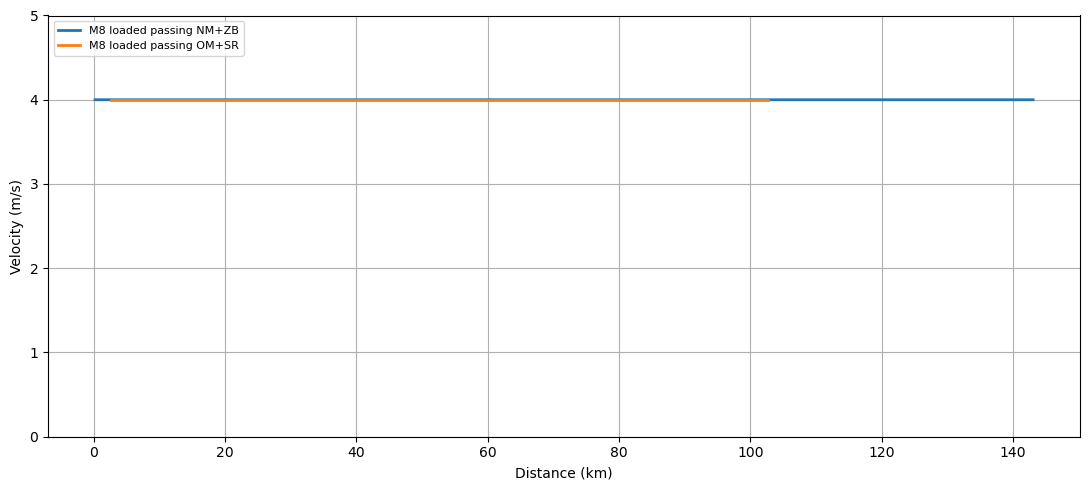

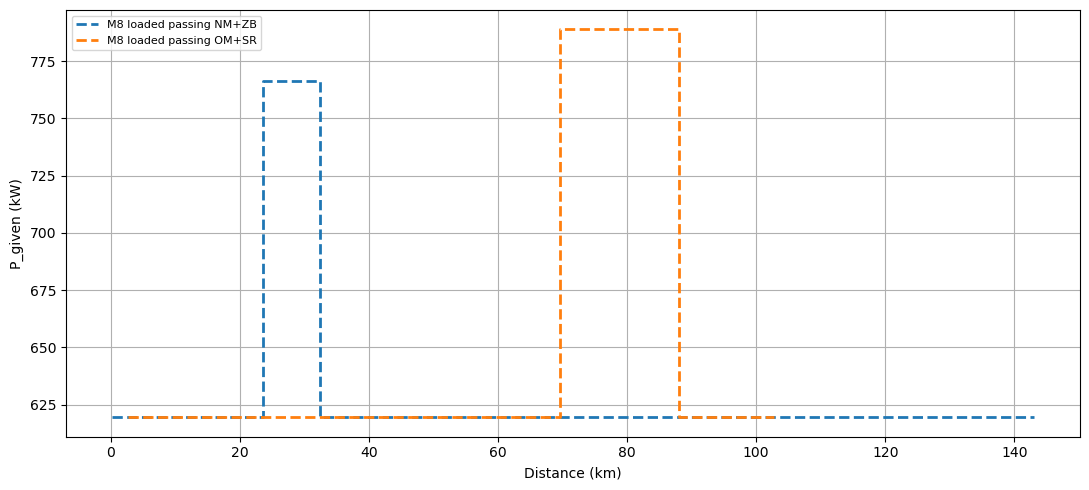

In [32]:
import matplotlib.pyplot as plt

df = df_eventtable_energy_H2.copy()
df = df.sort_values("start time")

#Keep only LOADED vessels
# df = df[df["object name"].str.contains(" loaded")]

# Keep only LOADED and 2 revelant ROUTES
df = df[
    df["object name"].str.contains(" loaded", na=False) &
    (
        df["object name"].str.contains("NM\\+ZB", na=False) |
        df["object name"].str.contains("OM\\+SR", na=False)
    )
]


# Prepare figure
fig, ax = plt.subplots(figsize=(11, 5))

base_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

# Group per route
for i, (route, g) in enumerate(df.groupby("object name")):

    g = g.copy()
    g["distance_cum_km"] = g["distance (m)"].cumsum() / 1000

    color = base_colors[i % len(base_colors)]

    ax.plot(
        g["distance_cum_km"],
        g["velocity (m/s)"],
        # drawstyle="steps-post",
        # linestyle="--",
        linewidth=2,
        color=color,
        label=route
    )

ax.set_xlabel("Distance (km)")
ax.set_ylabel("Velocity (m/s)")
ax.set_ylim(0,5)
ax.grid(True)
ax.legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.show()

# Copy & sort
df = df_eventtable_energy_H2.copy()
df = df.sort_values("start time")

# Keep only LOADED vessels
# df = df[df["object name"].str.contains(" loaded")]

# Keep only LOADED and 2 revelant ROUTES
df = df[
    df["object name"].str.contains(" loaded", na=False) &
    (
        df["object name"].str.contains("NM\\+ZB", na=False) |
        df["object name"].str.contains("OM\\+SR", na=False)
    )
]

# Prepare figure
fig, ax = plt.subplots(figsize=(11, 5))

base_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

# Group per route
for i, (route, g) in enumerate(df.groupby("object name")):

    g = g.copy()
    g["distance_cum_km"] = g["distance (m)"].cumsum() / 1000

    color = base_colors[i % len(base_colors)]

    ax.plot(
        g["distance_cum_km"],
        g["P_given (kW)"],
        drawstyle="steps-post",
        linestyle="--",
        linewidth=2,
        color=color,
        label=route
    )

ax.set_xlabel("Distance (km)")
ax.set_ylabel("P_given (kW)")
ax.grid(True)
ax.legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.show()


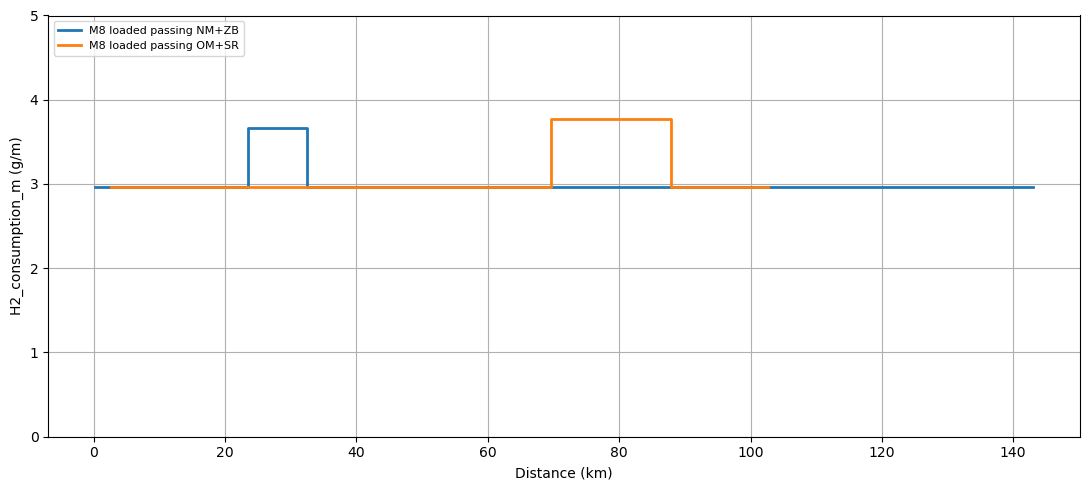

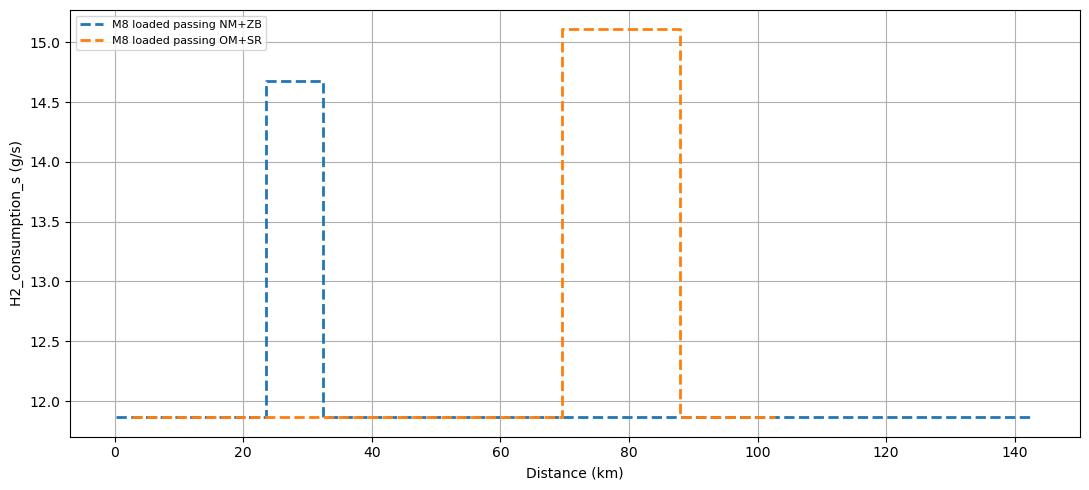

In [33]:
df = df_eventtable_energy_H2.copy()
df = df.sort_values("start time")

#Keep only LOADED vessels
# df = df[df["object name"].str.contains(" loaded")]

# Keep only LOADED and 2 revelant ROUTES
df = df[
    df["object name"].str.contains(" loaded", na=False) &
    (
        df["object name"].str.contains("NM\\+ZB", na=False) |
        df["object name"].str.contains("OM\\+SR", na=False)
    )
]


# Prepare figure
fig, ax = plt.subplots(figsize=(11, 5))

base_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

# Group per route
for i, (route, g) in enumerate(df.groupby("object name")):

    g = g.copy()
    g["distance_cum_km"] = g["distance (m)"].cumsum() / 1000

    color = base_colors[i % len(base_colors)]

    ax.plot(
        g["distance_cum_km"],
        g["H2_consumption_m (g/m)"],
        drawstyle="steps-post",
        # linestyle="--",
        linewidth=2,
        color=color,
        label=route
    )

ax.set_xlabel("Distance (km)")
ax.set_ylabel("H2_consumption_m (g/m)")
ax.set_ylim(0,5)
ax.grid(True)
ax.legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.show()

# Copy & sort
df = df_eventtable_energy_H2.copy()
df = df.sort_values("start time")

# Keep only LOADED vessels
# df = df[df["object name"].str.contains(" loaded")]

# Keep only LOADED and 2 revelant ROUTES
df = df[
    df["object name"].str.contains(" loaded", na=False) &
    (
        df["object name"].str.contains("NM\\+ZB", na=False) |
        df["object name"].str.contains("OM\\+SR", na=False)
    )
]

# Prepare figure
fig, ax = plt.subplots(figsize=(11, 5))

base_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

# Group per route
for i, (route, g) in enumerate(df.groupby("object name")):

    g = g.copy()
    g["distance_cum_km"] = g["distance (m)"].cumsum() / 1000

    color = base_colors[i % len(base_colors)]

    ax.plot(
        g["distance_cum_km"],
        g["H2_consumption_s (g/s)"],
        drawstyle="steps-post",
        linestyle="--",
        linewidth=2,
        color=color,
        label=route
    )

ax.set_xlabel("Distance (km)")
ax.set_ylabel("H2_consumption_s (g/s)")
ax.grid(True)
ax.legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.show()


#### Multipyling with fleet

In [34]:
# Insert count of vessels per route section 
Nieuwe_Maas   = 232
Oude_Maas     = 203
Zuid_Beveland = 182
Scheldt_Rhine = 271

Ratio_NM   = Nieuwe_Maas/(Nieuwe_Maas + Oude_Maas)
Ratio_OM   = Oude_Maas/(Nieuwe_Maas + Oude_Maas)
Ratio_ZB   = Zuid_Beveland/(Zuid_Beveland + Scheldt_Rhine)
Ratio_SR   = Scheldt_Rhine/(Zuid_Beveland + Scheldt_Rhine)

# Insert loading ratio
Ratio_loaded = 0.5
Ratio_empty  = 1 - Ratio_loaded 

In [35]:
# Insert total vessels 
total_vessels = 250

OM_SR_loaded  = total_vessels * Ratio_OM * Ratio_SR * Ratio_loaded
OM_SR_empty   = total_vessels * Ratio_OM * Ratio_SR * Ratio_empty
NM_SR_loaded  = total_vessels * Ratio_NM * Ratio_SR * Ratio_loaded
NM_SR_empty   = total_vessels * Ratio_NM * Ratio_SR * Ratio_empty
OM_ZB_loaded  = total_vessels * Ratio_OM * Ratio_ZB * Ratio_loaded
OM_ZB_empty   = total_vessels * Ratio_OM * Ratio_ZB * Ratio_empty
NM_ZB_loaded  = total_vessels * Ratio_NM * Ratio_ZB * Ratio_loaded
NM_ZB_empty   = total_vessels * Ratio_NM * Ratio_ZB * Ratio_empty

print("Computed route ratios ---")
print(f"NM ratio (Nieuwe / Total Maas) : {Ratio_NM:.3f} ({Ratio_NM:.1%})")
print(f"OM ratio (Oude / Total Maas)   : {Ratio_OM:.3f} ({Ratio_OM:.1%})")
print(f"ZB ratio (Zuid Beveland)       : {Ratio_ZB:.3f} ({Ratio_ZB:.1%})")
print(f"SR ratio (Scheldt–Rhine)       : {Ratio_SR:.3f} ({Ratio_SR:.1%})")

Computed route ratios ---
NM ratio (Nieuwe / Total Maas) : 0.533 (53.3%)
OM ratio (Oude / Total Maas)   : 0.467 (46.7%)
ZB ratio (Zuid Beveland)       : 0.402 (40.2%)
SR ratio (Scheldt–Rhine)       : 0.598 (59.8%)


#### Fleet totals

In [36]:
# Fleet definition
fleet_map = {
    "M8 loaded passing OM+SR": OM_SR_loaded,
    "M8 unloaded passing OM+SR": OM_SR_empty,
    "M8 loaded passing NM+SR": NM_SR_loaded,
    "M8 unloaded passing NM+SR": NM_SR_empty,
    "M8 loaded passing OM+ZB": OM_ZB_loaded,
    "M8 unloaded passing OM+ZB": OM_ZB_empty,
    "M8 loaded passing NM+ZB": NM_ZB_loaded,
    "M8 unloaded passing NM+ZB": NM_ZB_empty,
}

# Build fleet totals table (per vessel values)
summary_fleet_totals = (
    summary
    .loc[:, ['total_energy (kWh)', 'H2_consumption (kg)']]
    .rename(columns={
        'total_energy (kWh)': 'total_energy_vessel (kWh)',
        'H2_consumption (kg)': 'H2_consumption_vessel (kg)'
    })
)

# Add & round number of vessels BEFORE scaling
summary_fleet_totals.insert(
    0,
    'number of vessels',
    summary_fleet_totals.index.map(fleet_map).round(0).astype(int)
)

# Fleet totals
summary_fleet_totals['total_energy_fleet (kWh)'] = (
    summary_fleet_totals['total_energy_vessel (kWh)']
    * summary_fleet_totals['number of vessels']
)

summary_fleet_totals['H2_consumption_fleet (kg)'] = (
    summary_fleet_totals['H2_consumption_vessel (kg)']
    * summary_fleet_totals['number of vessels']
)

# Add TOTAL FLEET row
total_row = (
    summary_fleet_totals
    .sum()
    .to_frame()
    .T
)
total_row.index = ['TOTAL FLEET']

summary_fleet_totals = pd.concat(
    [summary_fleet_totals, total_row]
).round(2)

summary_fleet_totals

,number of vessels,total_energy_vessel (kWh),H2_consumption_vessel (kg),total_energy_fleet (kWh),H2_consumption_fleet (kg)
M8 loaded passing OM+SR,35.0,4632.88,319.42,162150.80,11179.7
M8 loaded passing NM+SR,40.0,5184.00,357.42,207360.00,14296.8
M8 loaded passing OM+ZB,23.0,5721.72,394.50,131599.56,9073.5
M8 loaded passing NM+ZB,27.0,6272.84,432.50,169366.68,11677.5
TOTAL FLEET,125.0,21811.44,1503.84,670477.04,46227.5
